# Instalación de librerías necesarias

In [1]:
!pip install datasets pandas matplotlib seaborn scikit-learn nltk spacy gensim transformers torch gradio wordcloud

In [2]:
import pandas as pd
from datasets import load_dataset

# Cargar el dataset (solo el split 'train', son ~100k reseñas)
dataset = load_dataset("beltrewilton/punta-cana-spanish-reviews", split ="train")

# Convertir a DataFrame
df = pd.DataFrame(dataset)

# Ver las primeras filas
print(df.shape)
df.head()

punta_cana.csv:   0%|          | 0.00/18.5M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

(34561, 6)


,hotel_name,location,wrote,rating,title,review_text
0,Secrets Cap Cana Resort & Spa,"Villaviciosa, Spain",December 2021,5,Vacaciones en El paraíso,El hotel impecable todo muy limpio las habitac...
1,Secrets Cap Cana Resort & Spa,"Villaviciosa, Spain",December 2021,5,HOTEL de la EXCELENCIA,"EXCELENTE, magnífico, excepcional, maravilloso..."
2,Secrets Cap Cana Resort & Spa,"Villaviciosa, Spain",December 2021,5,Sentirse como en CASA!!!!!,Tras conocer bastantes hoteles en distintos lu...
3,Secrets Cap Cana Resort & Spa,"Villaviciosa, Spain",December 2021,5,Muy buen nivel,Muy buen hotel. Cumple con todos los requisito...
4,Secrets Cap Cana Resort & Spa,"Villaviciosa, Spain",December 2021,5,10,Excelente todo ....sobre todo el personal. Es ...


# Crear columna de sentimiento

In [3]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return 0  # negativo
    elif rating == 3:
        return 1  # neutro
    else:
        return 2  # positivo

df['sentimiento'] = df['rating'].apply(rating_to_sentiment)

# Mapeo para legibilidad
sentimiento_map = {0:'negativo', 1:'neutro', 2:'positivo'}
from sklearn.utils import resample

# 1. Separar las clases
df_neg = df[df['sentimiento'] == 0]  # negativos
df_neu = df[df['sentimiento'] == 1]  # neutrales
df_pos = df[df['sentimiento'] == 2]  # positivos

print(f"Tamaños originales:")
print(f"Negativos: {len(df_neg)}")
print(f"Neutrales: {len(df_neu)}")
print(f"Positivos: {len(df_pos)}")

# 2. Tomar como referencia el tamaño de la clase más pequeña
# (o un múltiplo para no perder demasiados datos)
tamano_objetivo = len(df_neu)  # 345 - la clase más pequeña

# 3. Submuestrear las clases mayoritarias
df_neg_down = resample(df_neg,
                       replace=False,        # sin reemplazo = submuestreo
                       n_samples=tamano_objetivo,
                       random_state=42)

df_pos_down = resample(df_pos,
                       replace=False,
                       n_samples=tamano_objetivo,
                       random_state=42)

# 4. La clase neutral se queda igual (es la referencia)
df_neu_final = df_neu.copy()

# 5. Unir todo en un nuevo DataFrame balanceado
df = pd.concat([df_neg_down, df_neu_final, df_pos_down])

print(f"\nTamaños después del balanceo:")
print(f"Negativos: {len(df_neg_down)}")
print(f"Neutrales: {len(df_neu_final)}")
print(f"Positivos: {len(df_pos_down)}")
print(f"Total: {len(df)}")

# 6. Barajar el DataFrame para que no queden agrupados por clase
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nDataset balanceado listo para continuar con el preprocesamiento...")

df[['review_text','rating','sentimiento']].head()

Tamaños originales:
Negativos: 2234
Neutrales: 1695
Positivos: 30632

Tamaños después del balanceo:
Negativos: 1695
Neutrales: 1695
Positivos: 1695
Total: 5085

Dataset balanceado listo para continuar con el preprocesamiento...


,review_text,rating,sentimiento
0,En 2018 cumplimos cincuenta años de matrimonio...,5,2
1,"La playa, el clima, Mar y frutas es exquisito,...",3,1
2,Estuve en el hotel por una semana con 14 miemb...,3,1
3,"El mejor hotel del territorio Punta cana, Cap ...",5,2
4,"Me encantó todo es una maravilla, y lo que más...",4,2


# Instalación del modelo de spaCy para español

In [4]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 48.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# Definición de funciones de preprocesamiento

In [5]:
import re
import spacy
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('spanish'))

# Cargar modelo de spaCy
nlp = spacy.load("es_core_news_sm", disable=["ner", "parser"])  # solo necesitamos tokenizar y lematizar

# Palabras de negación a conservar (aunque estén en stopwords)
palabras_negacion = {'no','nunca','jamas','tampoco','ninguno','nadie','nada','sin','apenas'}

# Función de limpieza básica para texto crudo
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'http\S+|www.\S+', '', texto)  # URLs
    texto = re.sub(r'@\w+', '', texto)             # menciones
    texto = re.sub(r'[^a-záéíóúñü\s]', '', texto)  # solo letras y espacios (elimina puntuación)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Función de tokenización y lematización con filtro de stopwords (para ML clásico)
def tokenizar_lematizar(texto, eliminar_stopwords=True):
    doc = nlp(texto)
    tokens = []
    for token in doc:
        palabra = token.lemma_.lower()
        if eliminar_stopwords:
            if palabra not in stop_words or palabra in palabras_negacion:
                tokens.append(palabra)
        else:
            tokens.append(palabra)
    return tokens

# Función combinada para pipeline clásico (limpia + tokeniza)
def preprocesar_clasico(texto):
    texto_limpio = limpiar_texto(texto)
    tokens = tokenizar_lematizar(texto_limpio, eliminar_stopwords=True)
    return tokens  # devuelve lista de lemas

# Para el Transformer, solo limpieza ligera sin eliminar palabras
def preprocesar_transformer(texto):
    texto = texto.lower()
    texto = re.sub(r'http\S+|www.\S+', '', texto)
    texto = re.sub(r'@\w+', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto  # texto casi original, todo en minúsculas

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# 4. Representación vectorial
Para el modelo clásico usaremos TF‑IDF. Para el Transformer, usaremos su propio tokenizador que convierte el texto en ids.

# 4.1 TF‑IDF
Necesitamos unir los tokens en un string separado por espacios porque TfidfVectorizer espera texto.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Aplicamos el preprocesamiento clásico y unimos en un string
df['tokens'] = df['review_text'].apply(preprocesar_clasico)
df['texto_preprocesado'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))  # unigramas y bigramas
X_tfidf = vectorizer.fit_transform(df['texto_preprocesado'])
y = df['sentimiento'].values

# 5. Modelado de temas con LDA
Para mostrar de qué se habla en el corpus, ajustaremos un modelo LDA sobre los textos preprocesados (lemas sin stopwords). Usaremos gensim.

In [7]:
import gensim
from gensim import corpora

# Crear diccionario y corpus
dictionary = corpora.Dictionary(df['tokens'])
# Filtrar extremos
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

# Entrenar LDA (elegimos 5 temas, pueden ser los aspectos: comida, servicio...)
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                            id2word=dictionary,
                                            num_topics=5,
                                            random_state=42,
                                            passes=10)

# Ver las palabras principales de cada tema
for idx, topic in lda_model.print_topics(-1):
    print('Tema {}: {}'.format(idx, topic))

Tema 0: 0.015*"hacer" + 0.014*"haber" + 0.013*"personal" + 0.012*"empleado" + 0.011*"experiencia" + 0.010*"servicio" + 0.008*"sin" + 0.008*"cliente" + 0.008*"alguno" + 0.007*"si"
Tema 1: 0.028*"habitación" + 0.027*"haber" + 0.025*"tener" + 0.014*"día" + 0.011*"ir" + 0.009*"si" + 0.009*"llegar" + 0.009*"hacer" + 0.008*"sin" + 0.008*"playa"
Tema 2: 0.022*"tener" + 0.016*"haber" + 0.016*"hacer" + 0.015*"ir" + 0.013*"si" + 0.013*"decir" + 0.009*"poder" + 0.009*"pagar" + 0.008*"nada" + 0.008*"servicio"
Tema 3: 0.024*"excelente" + 0.017*"servicio" + 0.016*"mejor" + 0.015*"atención" + 0.014*"hacer" + 0.013*"buen" + 0.013*"siempre" + 0.012*"personal" + 0.011*"gracias" + 0.011*"especial"
Tema 4: 0.036*"comida" + 0.033*"buen" + 0.023*"servicio" + 0.022*"restaurante" + 0.020*"playa" + 0.016*"bien" + 0.015*"personal" + 0.015*"excelente" + 0.014*"calidad" + 0.014*"habitación"


# 6. Análisis de sentimiento clásico (Naive Bayes)
Dividimos los datos en entrenamiento y prueba, entrenamos un clasificador Naive Bayes y lo evaluamos.

Naive Bayes - Accuracy: 0.734, Precision: 0.735, Recall: 0.734, F1: 0.734


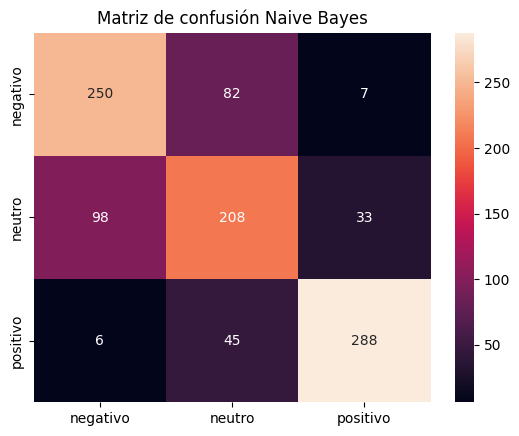

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

clf_nb = MultinomialNB()
clf_nb.fit(X_train, y_train)

y_pred_nb = clf_nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb, rec_nb, f1_nb, _ = precision_recall_fscore_support(y_test, y_pred_nb, average='weighted')

print(f"Naive Bayes - Accuracy: {acc_nb:.3f}, Precision: {prec_nb:.3f}, Recall: {rec_nb:.3f}, F1: {f1_nb:.3f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=sentimiento_map.values(), yticklabels=sentimiento_map.values())
plt.title('Matriz de confusión Naive Bayes')
plt.show()

# 7. Clasificador neuronal con BETO (Transformer)
Utilizaremos el modelo pre‑entrenado dccuchile/bert-base-spanish-wwm-uncased (BETO). Lo afinaremos para clasificación de sentimiento.

Importante: para el Transformer, usaremos el texto con preprocesamiento mínimo (solo minúsculas y limpieza de URLs/menciones). Conservamos puntuación y stopwords.

In [14]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split

# Texto para el Transformer
texts_transformer = df['review_text'].apply(preprocesar_transformer).tolist()
labels = df['sentimiento'].tolist()

# Dividir
train_texts, val_texts, train_labels, val_labels = train_test_split(texts_transformer, labels, test_size=0.2, random_state=42, stratify=labels)

# Tokenizar
tokenizer = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-uncased")
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=256)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=256)

# Crear dataset de PyTorch
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, train_labels)
val_dataset = ReviewDataset(val_encodings, val_labels)

# Modelo
model = AutoModelForSequenceClassification.from_pretrained(
    "dccuchile/bert-base-spanish-wwm-uncased",
    num_labels=3
)

# Argumentos de entrenamiento
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=100,
)

# Métrica personalizada
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# Entrenar (tarda unos minutos en GPU)
trainer.train()

# Evaluar en validación
preds_output = trainer.predict(val_dataset)
y_pred_trans = preds_output.predictions.argmax(-1)
acc_trans = accuracy_score(val_labels, y_pred_trans)
prec_trans, rec_trans, f1_trans, _ = precision_recall_fscore_support(val_labels, y_pred_trans, average='weighted')

print(f"Transformer - Accuracy: {acc_trans:.3f}, Precision: {prec_trans:.3f}, Recall: {rec_trans:.3f}, F1: {f1_trans:.3f}")

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.534769,0.505449,0.786627,0.788963
2,0.319477,0.516424,0.807276,0.808112


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Transformer - Accuracy: 0.807, Precision: 0.809, Recall: 0.807, F1: 0.808


# 8. Comparación de modelos con métricas
Ya tenemos las métricas de ambos modelos sobre el mismo conjunto de prueba. Lo presentarás en una tabla:

In [15]:
from sklearn.metrics import classification_report

print("=== Naive Bayes ===")
print(classification_report(y_test, y_pred_nb, target_names=['negativo','neutral','positivo'], zero_division=0))

print("=== BETO Transformer ===")
print(classification_report(val_labels, y_pred_trans, target_names=['negativo','neutral','positivo'], zero_division=0))

=== Naive Bayes ===
              precision    recall  f1-score   support

    negativo       0.71      0.74      0.72       339
     neutral       0.62      0.61      0.62       339
    positivo       0.88      0.85      0.86       339

    accuracy                           0.73      1017
   macro avg       0.74      0.73      0.73      1017
weighted avg       0.74      0.73      0.73      1017

=== BETO Transformer ===
              precision    recall  f1-score   support

    negativo       0.78      0.78      0.78       339
     neutral       0.71      0.72      0.72       339
    positivo       0.94      0.91      0.93       339

    accuracy                           0.81      1017
   macro avg       0.81      0.81      0.81      1017
weighted avg       0.81      0.81      0.81      1017



# 9. Sentimiento por aspecto (comida, servicio, limpieza, precio)
Como no tenemos etiquetas de aspecto en el dataset, haremos una extracción basada en palabras clave y luego clasificaremos el sentimiento de las frases que contengan esas palabras.

# 9.1 Definir diccionarios de aspectos

In [16]:
aspectos = {
    'comida': ['comida','desayuno','cena','restaurante','plato','menú','buffet','sabor','platos','comer'],
    'servicio': ['servicio','personal','atención','recepcionista','camarero','staff','empleados','trato'],
    'limpieza': ['limpieza','limpio','sucio','aseo','habitación limpia','baño limpio'],
    'precio': ['precio','coste','caro','barato','relación calidad-precio','costo','tarifa','gastos']
}

# 9.2 Función para extraer sentimiento por aspecto
Podemos usar un modelo de análisis de sentimiento pre‑entrenado en español para clasificar el fragmento extraído. O, más sencillo, usar las predicciones que ya hicimos a nivel de reseña, pero eso no es preciso. Mejor:

Detectar oraciones que contengan palabras del aspecto.

Pasar esas oraciones por nuestro modelo BETO afinado (o uno de sentimiento general en español como finiteautomata/beto-sentiment-analysis que distingue positivo/negativo).

Agregar los resultados.

Crearemos una función sentimiento_aspectos(texto):



In [17]:
from transformers import pipeline

# Cargamos un pipeline de análisis de sentimiento en español (más ligero)
sentiment_pipeline = pipeline("sentiment-analysis", model="finiteautomata/beto-sentiment-analysis", top_k=None)

def sentimiento_aspectos(texto):
    # Limpiar ligeramente
    texto = preprocesar_transformer(texto)
    # Separar en oraciones (usando punto como separador simple)
    oraciones = re.split(r'[.!?]', texto)
    resultados = {}
    for aspecto, palabras in aspectos.items():
        oraciones_aspecto = [orac.strip() for orac in oraciones if any(p in orac for p in palabras)]
        if not oraciones_aspecto:
            resultados[aspecto] = 'neutral'  # sin menciones
            continue
        # Unir para pasarlo al pipeline
        fragmento = '. '.join(oraciones_aspecto)
        pred = sentiment_pipeline(fragmento[:512])[0]  # recortamos a 512 tokens
        # pred es una lista de dicts con label y score, ej: [{'label':'NEG','score':0.9}, {'label':'POS','score':0.1}]
        # Buscamos el label con mayor score
        etiqueta = max(pred, key=lambda x: x['score'])['label']
        # Mapear a nuestro formato
        if 'POS' in etiqueta:
            sent = 'positivo'
        elif 'NEG' in etiqueta:
            sent = 'negativo'
        else:
            sent = 'neutral'
        resultados[aspecto] = sent
    return resultados

# Ejemplo
print(sentimiento_aspectos("La comida era deliciosa pero el servicio muy malo y la habitación estaba sucia."))

config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/528 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/481k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

{'comida': 'negativo', 'servicio': 'negativo', 'limpieza': 'neutral', 'precio': 'neutral'}


# 10. Interfaz con Gradio
Crearemos una interfaz que permita dos modos:

Pegar una reseña y ver el sentimiento general, los aspectos y el tema de LDA más probable.

Subir un archivo CSV con reseñas y mostrar resumen (distribución de sentimiento, temas principales, nube de palabras).

Guardaremos los modelos y objetos necesarios con joblib o pickle para usarlos en la interfaz.

# 10.1 Guardar modelos

In [18]:
import joblib

# Modelo clásico
joblib.dump(clf_nb, 'modelo_nb.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

# LDA
lda_model.save('modelo_lda.model')
dictionary.save('dictionary_lda.dict')

# Transformer (BETO afinado)
trainer.save_model('modelo_beto')
tokenizer.save_pretrained('modelo_beto')
model_beto = model
tokenizer_beto = tokenizer

print("Modelos guardados correctamente.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelos guardados correctamente.


# 10.2 Crear la interfaz (en un archivo app.py o en una celda especial de Colab)

In [ ]:
import gradio as gr
import torch
import pandas as pd
import matplotlib.pyplot as plt
import re, unicodedata, traceback

plt.rcParams.update({'axes.edgecolor': '#334155', 'text.color': '#e6e9ef',
                     'axes.labelcolor': '#e6e9ef', 'xtick.color': '#cbd5e1',
                     'ytick.color': '#cbd5e1'})

# ============ MÉTRICAS (pega aquí tus números reales si cambian) ============
METRICAS = {
    "Naive Bayes (TF-IDF)": {"Accuracy": 0.734, "Precision": 0.735, "Recall": 0.734, "F1": 0.734,
                             "f1_clase": {"negativo": 0.72, "neutral": 0.62, "positivo": 0.86}},
    "BETO (Transformer)":   {"Accuracy": 0.807, "Precision": 0.809, "Recall": 0.807, "F1": 0.808,
                             "f1_clase": {"negativo": 0.78, "neutral": 0.72, "positivo": 0.93}},
}
STATS = {"Reseñas de entrenamiento (balanceadas)": "5.085", "Por clase": "1.695 c/u",
         "Conjunto de prueba": "1.017", "Mejor modelo": "BETO — 80.7% accuracy"}

# ============ Helper acentos ============
def _norm(s):
    s = s.lower()
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

# ============ Predicción (maneja GPU/CPU) ============
def predecir_estrellas(texto):
    texto_limpio = preprocesar_transformer(texto)
    device = next(model_beto.parameters()).device
    inputs = tokenizer_beto(texto_limpio, return_tensors="pt", truncation=True, max_length=256)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model_beto.eval()
    with torch.no_grad():
        outputs = model_beto(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1).squeeze().cpu().tolist()
    estrellas = probs[0]*1.5 + probs[1]*3 + probs[2]*4.5
    estrellas = round(estrellas * 2) / 2
    etiqueta = {0:'negativo', 1:'neutral', 2:'positivo'}[int(torch.tensor(probs).argmax())]
    return estrellas, etiqueta

def sentimiento_aspectos(texto):
    texto_n = _norm(preprocesar_transformer(texto))
    oraciones = re.split(r'[.!?,;]', texto_n)
    resultados = {}
    for aspecto, palabras in aspectos.items():
        claves = [_norm(p) for p in palabras]
        oraciones_aspecto = [o.strip() for o in oraciones if any(c in o for c in claves)]
        if not oraciones_aspecto:
            resultados[aspecto] = 'neutral'; continue
        pred = sentiment_pipeline('. '.join(oraciones_aspecto)[:512])[0]
        etiqueta = max(pred, key=lambda x: x['score'])['label']
        resultados[aspecto] = 'positivo' if 'POS' in etiqueta else ('negativo' if 'NEG' in etiqueta else 'neutral')
    return resultados

# ============ Gráfico comparativo (fondo oscuro) ============
def build_metrics_fig():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
    fig.patch.set_facecolor('#161a23')
    modelos = list(METRICAS.keys())
    colores = ['#64748b', '#2dd4bf']

    mets = ["Accuracy", "Precision", "Recall", "F1"]
    x = range(len(mets)); w = 0.35
    for i, m in enumerate(modelos):
        vals = [METRICAS[m][k] for k in mets]
        ax1.bar([p + i*w for p in x], vals, w, label=m, color=colores[i])
    ax1.set_facecolor('#161a23'); ax1.set_ylim(0, 1); ax1.set_title("Métricas globales", color='#e6e9ef', fontweight='bold')
    ax1.set_xticks([p + w/2 for p in x]); ax1.set_xticklabels(mets); ax1.legend(facecolor='#1c2130', labelcolor='#e6e9ef', fontsize=8)

    clases = ["negativo", "neutral", "positivo"]; xc = range(len(clases))
    for i, m in enumerate(modelos):
        vals = [METRICAS[m]["f1_clase"][c] for c in clases]
        ax2.bar([p + i*w for p in xc], vals, w, label=m, color=colores[i])
    ax2.set_facecolor('#161a23'); ax2.set_ylim(0, 1); ax2.set_title("F1 por clase", color='#e6e9ef', fontweight='bold')
    ax2.set_xticks([p + w/2 for p in xc]); ax2.set_xticklabels([c.capitalize() for c in clases])
    fig.tight_layout()
    return fig

def tabla_metricas_html():
    filas = ""
    for m, d in METRICAS.items():
        destacado = "color:#2dd4bf; font-weight:700;" if "BETO" in m else "color:#cbd5e1;"
        filas += f"""<tr>
            <td style="padding:10px 14px; {destacado}">{m}</td>
            <td style="padding:10px 14px; text-align:center;">{d['Accuracy']:.3f}</td>
            <td style="padding:10px 14px; text-align:center;">{d['Precision']:.3f}</td>
            <td style="padding:10px 14px; text-align:center;">{d['Recall']:.3f}</td>
            <td style="padding:10px 14px; text-align:center;">{d['F1']:.3f}</td></tr>"""
    return f"""
    <div class="card">
      <h3 style="margin-top:0;">📊 Comparativa: clásico vs. moderno</h3>
      <table style="width:100%; border-collapse:collapse; color:#e6e9ef;">
        <tr style="border-bottom:1px solid #334155; color:#94a3b8; font-size:13px;">
          <th style="text-align:left; padding:8px 14px;">Modelo</th><th>Accuracy</th><th>Precision</th><th>Recall</th><th>F1</th></tr>
        {filas}
      </table>
      <p style="color:#94a3b8; font-size:13px; margin-bottom:0;">BETO supera al clásico en ~7 puntos. La clase <b>neutral</b> es la más difícil en ambos, pero el Transformer la mejora notablemente.</p>
    </div>"""

def stats_html():
    tarjetas = ""
    for k, v in STATS.items():
        tarjetas += f"""<div class="stat-box"><div class="stat-num">{v}</div><div class="stat-lbl">{k}</div></div>"""
    return f"<div class='stats-grid'>{tarjetas}</div>"

# ============ CSS oscuro ============
custom_css = """
.gradio-container { background:#0f1117 !important; font-family:'Segoe UI',system-ui,sans-serif; color:#e6e9ef !important; }
.card { background:#1c2130; border:1px solid #2a3140; border-radius:16px; padding:22px; margin-top:8px; box-shadow:0 4px 14px rgba(0,0,0,0.35); }
.badge-positivo { background:rgba(34,197,94,.15) !important; color:#4ade80 !important; padding:4px 12px !important; border-radius:12px !important; font-weight:600 !important; border:1px solid #22c55e !important; }
.badge-negativo { background:rgba(239,68,68,.15) !important; color:#f87171 !important; padding:4px 12px !important; border-radius:12px !important; font-weight:600 !important; border:1px solid #ef4444 !important; }
.badge-neutral { background:rgba(148,163,184,.15) !important; color:#cbd5e1 !important; padding:4px 12px !important; border-radius:12px !important; font-weight:600 !important; border:1px solid #64748b !important; }
.aspecto-fila { display:flex; justify-content:space-between; padding:10px 14px; border-bottom:1px solid #2a3140; }
.aspecto-nombre { text-transform:capitalize; color:#e6e9ef; }
.resultado-container { background:#1c2130; border:1px solid #2a3140; border-radius:16px; padding:22px; }
.estrellas-display { font-size:34px; color:#fbbf24; letter-spacing:3px; text-align:center; }
.mensaje-error { color:#f87171; font-weight:bold; }
.stats-grid { display:grid; grid-template-columns:repeat(2,1fr); gap:12px; }
.stat-box { background:#1c2130; border:1px solid #2a3140; border-radius:14px; padding:16px; text-align:center; }
.stat-num { font-size:22px; font-weight:700; color:#2dd4bf; }
.stat-lbl { font-size:12px; color:#94a3b8; margin-top:4px; }
"""

iconos = {"positivo":"🟢","negativo":"🔴","neutral":"⚪"}

def render_resultado(texto):
    if not texto or not texto.strip():
        return "<p class='mensaje-error'>Por favor pega una reseña.</p>"
    try:
        estrellas, etiqueta = predecir_estrellas(texto)
        aspectos_res = sentimiento_aspectos(texto)
        n = int(round(estrellas)); estrellas_html = "★"*n + "☆"*(5-n)
        filas = ""
        for asp, sent in aspectos_res.items():
            filas += f"""<div class="aspecto-fila"><span class="aspecto-nombre">{asp}</span>
                <span class="badge-{sent}">{iconos.get(sent,'⚪')} {sent.capitalize()}</span></div>"""
        return f"""<div class="resultado-container">
            <div style="text-align:center; margin-bottom:16px;">
                <div class="estrellas-display">{estrellas_html}</div>
                <div style="color:#94a3b8; font-size:13px; margin-top:2px;">Estrellas estimadas: {estrellas:.1f} / 5</div>
                <span class="badge-{etiqueta}" style="margin-top:10px; display:inline-block;">Sentimiento general: {etiqueta.capitalize()}</span>
            </div>
            <h4 style="color:#e6e9ef; margin:0 0 10px 4px;">Sentimiento por aspecto</h4>
            <div style="border:1px solid #2a3140; border-radius:10px; overflow:hidden;">{filas}</div>
        </div>"""
    except Exception as e:
        return f"<pre class='mensaje-error'>⚠️ {e}\n\n{traceback.format_exc()}</pre>"

def analizar_csv(archivo):
    if archivo is None:
        return "<p class='mensaje-error'>Por favor sube un archivo CSV.</p>", None
    try:
        df_csv = pd.read_csv(archivo.name)
        if 'review_text' not in df_csv.columns:
            return "<p class='mensaje-error'>El CSV debe tener una columna 'review_text'.</p>", None
        resultados = df_csv['review_text'].astype(str).apply(lambda t: predecir_estrellas(t)[1])
        conteo = resultados.value_counts(); total = len(resultados)
        colores = {"positivo":"#22c55e","negativo":"#ef4444","neutral":"#94a3b8"}
        filas = ""
        for e in ["positivo","neutral","negativo"]:
            pct = (conteo.get(e,0)/total*100) if total>0 else 0
            filas += f"<p style='color:{colores.get(e)}; margin:4px 0;'><b>{e.capitalize()}</b>: {pct:.1f}%</p>"
        resumen = f"<div class='card'><p style='font-size:16px;'>Total analizadas: <b>{total}</b></p>{filas}</div>"
        fig, ax = plt.subplots(figsize=(5,5)); fig.patch.set_facecolor('#0f1117')
        ax.pie(conteo.values, labels=[k.capitalize() for k in conteo.index], autopct='%1.1f%%',
               colors=[colores.get(i,'#ccc') for i in conteo.index], startangle=90,
               textprops={'fontsize':12,'color':'#e6e9ef'})
        ax.set_title("Distribución de sentimientos", color='#e6e9ef', fontweight='bold', pad=18)
        return resumen, fig
    except Exception as e:
        return f"<pre class='mensaje-error'>⚠️ {e}\n\n{traceback.format_exc()}</pre>", None

# ============ Forzar modo oscuro ============
js_dark = """
function() {
    const url = new URL(window.location);
    if (url.searchParams.get('__theme') !== 'dark') {
        url.searchParams.set('__theme', 'dark');
        window.location.href = url.href;
    }
}
"""

with gr.Blocks(css=custom_css, theme=gr.themes.Soft(primary_hue="teal", neutral_hue="slate"), js=js_dark) as demo:
    gr.Markdown("<h1 style='text-align:center; color:#f1f5f9; margin-bottom:0;'>🏨 Analizador de Reseñas de Hoteles</h1>")
    gr.Markdown("<p style='text-align:center; color:#94a3b8; margin-top:5px;'>Sentimiento por aspecto · estrellas estimadas · clásico vs. Transformer</p>")

    with gr.Tab("📝 Reseña individual"):
        entrada = gr.Textbox(lines=6, label="Reseña",
                             placeholder="Ej: El hotel estaba limpio y el personal amable, aunque el desayuno dejó que desear...")
        boton = gr.Button("🔍 Analizar", variant="primary")
        salida = gr.HTML()
        boton.click(fn=render_resultado, inputs=entrada, outputs=salida)
        gr.Examples(examples=[
            ["El hotel estaba impecable, el personal súper amable, pero el desayuno dejó mucho que desear."],
            ["Pésima atención en recepción, la habitación sucia y muy caro para lo que ofrece."],
            ["Todo excelente, la mejor experiencia de nuestras vacaciones, sin duda regresaríamos."],
        ], inputs=entrada)

    with gr.Tab("📊 Análisis por lote (CSV)"):
        archivo = gr.File(label="Sube un CSV con columna 'review_text'", file_types=[".csv"])
        boton_csv = gr.Button("📈 Analizar lote", variant="primary")
        resumen_html = gr.HTML(); grafico = gr.Plot()
        boton_csv.click(fn=analizar_csv, inputs=archivo, outputs=[resumen_html, grafico])

    with gr.Tab("📈 Métricas del modelo"):
        gr.Markdown("<h3 style='color:#f1f5f9;'>Estadísticas del corpus</h3>")
        gr.HTML(stats_html())
        gr.HTML(tabla_metricas_html())
        gr.Plot(value=build_metrics_fig())

demo.launch(share=True, debug=True)

/tmp/ipykernel_4451/1359738846.py:184: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css, js. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft(primary_hue="teal", neutral_hue="slate"), js=js_dark) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://aed1f95694fbe62203.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/di